### Open ended stub antenna

An open-ended stub antenna is a simple radiating element consisting of a transmission line (typically microstrip or coaxial cable) with one end open-circuited, allowing electromagnetic energy to radiate directly into free space.

In [1]:
import gmsh
import math

from palacetoolkit.viz import view_mesh
from palacetoolkit.mesh import (
    Entity, 
    run_meshing_pipeline, 
    generate_3d_mesh, 
    refine_near_surfaces
)
from palacetoolkit.simulation import Simulation

### Paramters
- l1 : Ground plane length along x-axis, specified as a scalar in meters
- w1 : Ground plane width along y-axis, specified as a scalar in meters
- h : Patch height along z-axis, specified as a scalar in meters.

- strip_line_length : Notch length along x-axis, specified as a scalar in meters. 
- strip_lined_width: Notch width along y-axis, specified as a scalar in meters.
- air_height : Air box height along z-axis, specified as a scalar in meters.  
- air_margin : Air box margin along x and y axes, specified as a scalar in meters.
- freq  : Simulation frequency in GHz, specified as a scalar.
- filename : Output mesh filename, specified as a string.

In [2]:
l1: float = 0.06
w1: float = 0.06
strip_line_length: float = 0.04
strip_line_width: float = 0.002
h: float = 0.0013
air_height: float = 0.025    
air_margin: float = 0.025    
freq: float = 3.3
filename: str = "sw_antenna.msh"

wavelength = 3e8 / (freq * 1e9)

### Model initialization

In [3]:
gmsh.initialize()
gmsh.model.add("patch_antenna")
kernel = gmsh.model.occ

### Geometry construction

In [4]:
# Total domain bounds
total_xmin = -l1/2 - air_margin
total_xmax = l1/2 + air_margin
total_ymin = -w1/2 - air_margin
total_ymax = w1/2 + air_margin
total_zmax = h + air_height

# Substrate box
substrate = kernel.addBox(-l1/2, -w1/2, 0, l1, w1, h)

# Ground plane
ground_plane = kernel.addRectangle(-l1/2, -w1/2, 0, l1, w1)

# Top conductor
strip_line_1 = kernel.addRectangle(-l1/2, -strip_line_width/2, h, strip_line_length, strip_line_width)

# gap bewteen the ground plane and the bottom of the lumped port.
gap = 0

# lumped port
lumped_port = kernel.addRectangle(-l1/2 + gap, -strip_line_width/2, 0, h - gap, strip_line_width)
kernel.rotate([(2, lumped_port)], -l1/2, 0, 0, 0, 1, 0, -math.pi/2)

# Airbox
air_box = kernel.addBox(
    total_xmin, total_ymin, 0,
    total_xmax - total_xmin,
    total_ymax - total_ymin,
    total_zmax
)

# Synchronize everything!
kernel.synchronize()

In [5]:
# Define the entities which later will become the physical groups.
entities = [
    Entity("air_box", dim = 3, mesh_order = 2, tags = [air_box]),
    Entity("substrate", dim = 3, mesh_order = 1, tags = [substrate]),
    Entity("top_conductor", dim = 2, mesh_order= 1, tags = [strip_line_1]),
    Entity("ground_plane", dim = 2, mesh_order = 1, tags = [ground_plane]),
    Entity("lumped_port", dim = 2, mesh_order = 0, tags = [lumped_port])
]

# Boolean operations to guarantee a nice mesh, algo it returns the
# physical group map.
pg_map = run_meshing_pipeline(entities)

# Refine near the top conductor and locally the lumped port
refine_near_surfaces(entities[2].dimtags, 
                     wavelength, 
                     ppw_near=50, 
                     ppw_far=30, 
                     set_as_background=True,
                     local_refinements = {entities[-1].dimtags[0]: 150})
# Mesh sizes
mesh_sizes = {
    "substrate": wavelength / 12,
    "air_box": wavelength / 4,
    "lumped_port": wavelength / 150,
    "ground_plane" : wavelength / 10,
    "top_conductor": wavelength / 50
}

# Generate the 3d mesh.
generate_3d_mesh(entities, mesh_sizes, filename, optimize = True)

  Physical group 'air_box' (dim=3): pg=1, tags=[2]
  Physical group 'substrate' (dim=3): pg=2, tags=[1]
  Physical group 'top_conductor' (dim=2): pg=3, tags=[8]
  Physical group 'ground_plane' (dim=2): pg=4, tags=[7]
  Physical group 'lumped_port' (dim=2): pg=5, tags=[9]
  Physical group 'air_box__None' (dim=2): pg=6, tags=[16, 17, 18, 19, 20, 21]
  Physical group 'air_box__substrate' (dim=2): pg=7, tags=[10, 11, 13, 12, 14, 15]
  ppw_near=50  ppw_far=30
  SizeMax=0.0030  transition=0.0227
  global: 4 curves, SizeMin=0.0018
  local (2, 9): 4 curves, SizeMin=0.0006
  Merged 2 fields with Min → field 5
Info    : Meshing 1D...
Info    : [  0%] Meshing curve 24 (Line)
Info    : [ 10%] Meshing curve 25 (Line)
Info    : [ 10%] Meshing curve 26 (Line)
Info    : [ 10%] Meshing curve 27 (Line)
Info    : [ 20%] Meshing curve 28 (Line)
Info    : [ 20%] Meshing curve 29 (Line)
Info    : [ 20%] Meshing curve 30 (Line)
Info    : [ 30%] Meshing curve 31 (Line)
Info    : [ 30%] Meshing curve 32 (Line)

Info    : [ 90%] Meshing surface 19 (Plane, MeshAdapt)
Info    : [ 90%] Meshing surface 20 (Plane, MeshAdapt)
Info    : [100%] Meshing surface 21 (Plane, MeshAdapt)
Info    : Done meshing 2D (Wall 0.2917s, CPU 0.292513s)
Info    : Meshing 3D...
Info    : 3D Meshing 2 volumes with 1 connected component
Info    : Tetrahedrizing 6311 nodes...
Info    : Done tetrahedrizing 6319 nodes (Wall 0.0937763s, CPU 0.08521s)
Info    : Reconstructing mesh...


Info    :  - Creating surface mesh
Info    :  - Identifying boundary edges
Info    :  - Recovering boundary
Info    : Done reconstructing mesh (Wall 0.338194s, CPU 0.310416s)


Info    : Found volume 2
Info    : Found volume 1
Info    : It. 0 - 0 nodes created - worst tet radius 12.4961 (nodes removed 0 0)
Info    : It. 500 - 500 nodes created - worst tet radius 2.25786 (nodes removed 0 0)
Info    : It. 1000 - 1000 nodes created - worst tet radius 1.8495 (nodes removed 0 0)
Info    : It. 1500 - 1500 nodes created - worst tet radius 1.64962 (nodes removed 0 0)


Info    : It. 2000 - 2000 nodes created - worst tet radius 1.52633 (nodes removed 0 0)
Info    : It. 2500 - 2500 nodes created - worst tet radius 1.42558 (nodes removed 0 0)
Info    : It. 3000 - 3000 nodes created - worst tet radius 1.34507 (nodes removed 0 0)
Info    : It. 3500 - 3500 nodes created - worst tet radius 1.28332 (nodes removed 0 0)
Info    : It. 4000 - 4000 nodes created - worst tet radius 1.23319 (nodes removed 0 0)
Info    : It. 4500 - 4500 nodes created - worst tet radius 1.18791 (nodes removed 0 0)
Info    : It. 5000 - 5000 nodes created - worst tet radius 1.15195 (nodes removed 0 0)


...

Info    : 26 elements combined 
Info    : ImproveMesh 
Info    : Total badness = 76927.5 
Info    : Total badness = 76881.9 
Info    : SplitImprove 
Info    : badmax = 8.99387 
Info    : 0 splits performed 


Info    : ImproveMesh 
Info    : Total badness = 76881.9 
Info    : Total badness = 76872.4 
Info    : SwapImprove  


Info    : 224 swaps performed 
Info    : SwapImprove2  


Info    : 0 swaps performed 
Info    : ImproveMesh 
Info    : Total badness = 76796.8 
Info    : Total badness = 76657.8 
Info    : Done optimizing mesh (Wall 4.83401s, CPU 4.83476s)
Info    : Writing 'sw_antenna.msh'...


Mesh saved to sw_antenna.mshInfo    : Done writing 'sw_antenna.msh'

  Nodes: 14234
  Elements: 81567


### Mesh visualization.

Loading mesh file: sw_antenna.msh
Groups to render transparent: air_box__None



Mesh loaded successfully with 2 cell blocks
Found 12717 triangles total
Physical group tags in mesh: {3: 'top_conductor', 4: 'ground_plane', 5: 'lumped_port', 6: 'air_box__None', 7: 'air_box__substrate'}



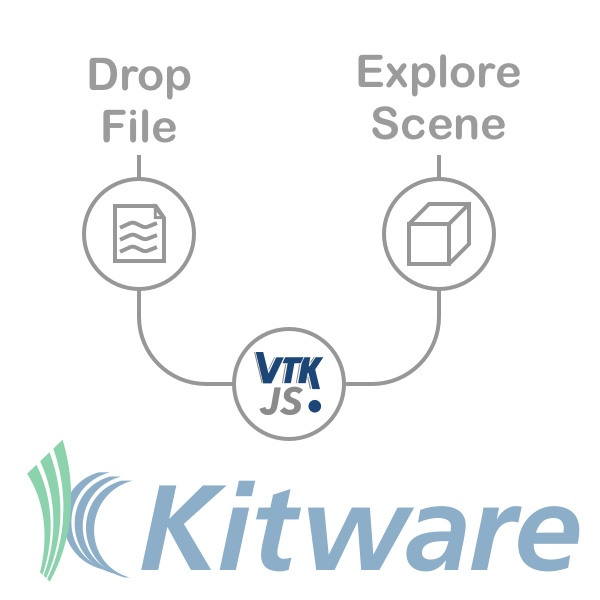

In [6]:
# Render the physical groups. The airbox is rendered transparent.
view_mesh(filename, transparent_groups= "air_box__None")

### Generate palace JSON config

In [7]:
config_filename: str = "palace.conf"
freq_min: float = 3.0
freq_max: float = 3.5
freq_step: float = 0.005
eps_r: float = 2.2
loss_tan: float = 0.0009
port_impedance: float = 50.0
solver_order: int = 2

In [8]:
sim = Simulation()

def attr(name):
    return [pg_map[name]] if name in pg_map else []

sim.set_mesh_file(f"/work/{filename}")
sim.set_config_option("Problem.Output", "/work/results/open_ended_antenna/")

sim.set_config_option("Domains.Materials", [
    {
        "Attributes": attr("substrate"),
        "Permittivity": eps_r,
        "Permeability": 1.0,
        "LossTan": loss_tan
    },
    {
        "Attributes": attr("air"),
        "Permittivity": 1.0,
        "Permeability": 1.0
    }
])

sim.set_config_option("Boundaries.PEC", {
    "Attributes": attr("ground_plane") + attr("patch")
})
sim.set_config_option("Boundaries.LumpedPort", [
    {
        "Index": 1,
        "Attributes": attr("lumped_port"),
        "R": port_impedance,
        "Excitation": True,
        "Direction": "+Z"
    }
])
sim.set_config_option("Boundaries.Absorbing", {
    "Attributes": attr("farfield"),
    "Order": 1
})

sim.set_config_option("Solver.Order", solver_order)
sim.set_config_option("Solver.Driven.MinFreq", freq_min)
sim.set_config_option("Solver.Driven.MaxFreq", freq_max)
sim.set_config_option("Solver.Driven.FreqStep", freq_step)
sim.set_config_option("Solver.Driven.AdaptiveTol", 0.001)

config_path = sim.write_config(config_filename)
print(f"Wrote {config_path}")

Palace config written to palace.conf
Wrote palace.conf
